In [ ]:
# Data collection command:
# `python comet_download.py --project=eliminate-step-size --n_threads=8`

In [1]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.analysis_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [2]:
save_path = 'figures/'
config_data_path = 'data/eliminate-step-size_params.csv'
run_data_path = 'data/eliminate-step-size_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
# del config_dfs[np.nan], run_dfs[np.nan]

{k: len(v) for k, v in config_dfs.items()}

{'ideal_features': 42, 'cbp_utility': 84, 'mean_initial_step_size': 26}

In [3]:
print("_____Best Hyperparameter Configurations_____")

sweep_split_vars = {
    'cbp_utility': ['feature_recycling|use_signed_utility'],
    'mean_initial_step_size': ['feature_recycling|initial_step_size_method'],
}

best_config_dfs, best_run_dfs, best_var_vals = get_best_ablation_values(
    config_dfs, run_dfs, sweep_split_vars=sweep_split_vars)

_____Best Hyperparameter Configurations_____

=== ideal_features ===

Configuration: (no split vars) | # runs: 1
  Best optimizer|meta_learning_rate=2**-6
  Best optimizer|learning_rate=2**-18


=== cbp_utility ===

Configuration: feature_recycling|use_signed_utility=False | # runs: 1
  Best optimizer|meta_learning_rate=2**-5
  Best optimizer|learning_rate=2**-14

Configuration: feature_recycling|use_signed_utility=True | # runs: 1
  Best optimizer|meta_learning_rate=2**-3
  Best optimizer|learning_rate=2**-18


=== mean_initial_step_size ===

Configuration: feature_recycling|initial_step_size_method=constant | # runs: 1
  Best optimizer|learning_rate=2**-15

Configuration: feature_recycling|initial_step_size_method=mean | # runs: 1
  Best optimizer|learning_rate=2**-15



In [7]:
best_run_dfs['ideal_features']
max_step = best_run_dfs['ideal_features']['step'].max()
threshold_step = int(max_step * 0.95)
ideal_loss = best_run_dfs['ideal_features']['loss'][
    best_run_dfs['ideal_features']['step'] >= threshold_step
].mean()

## Learning Curves

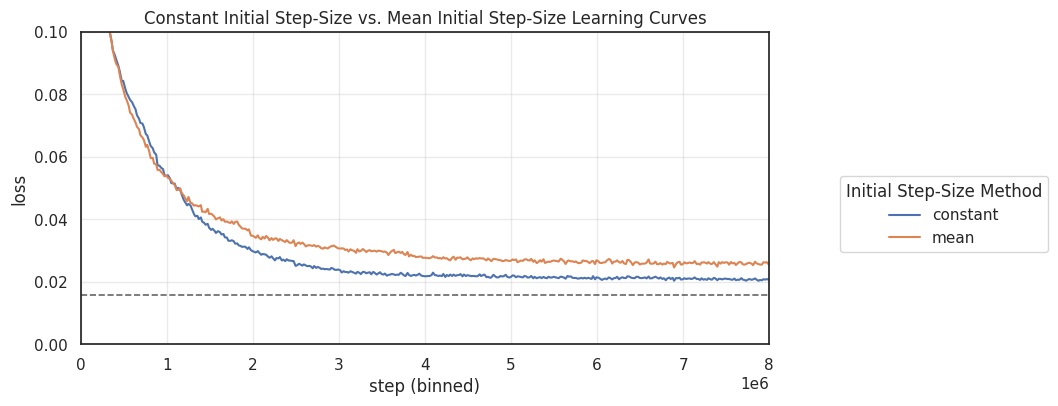

In [8]:
plot_learning_curves(
    run_df = best_run_dfs['mean_initial_step_size'],
    config_df = best_config_dfs['mean_initial_step_size'],
    n_bins = 1000,
    figsize = (8, 4),
    max_cols = 1,
    hue_col = 'feature_recycling|initial_step_size_method',
    legend_title = 'Initial Step-Size Method',
)
plt.ylim(0.0, 0.1)
plt.axhline(ideal_loss, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
plt.title('Constant Initial Step-Size vs. Mean Initial Step-Size Learning Curves')
plt.show()

## Hyperparameter Sensitivity

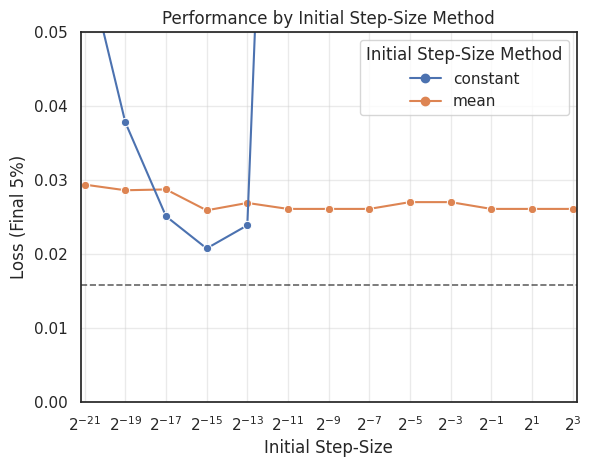

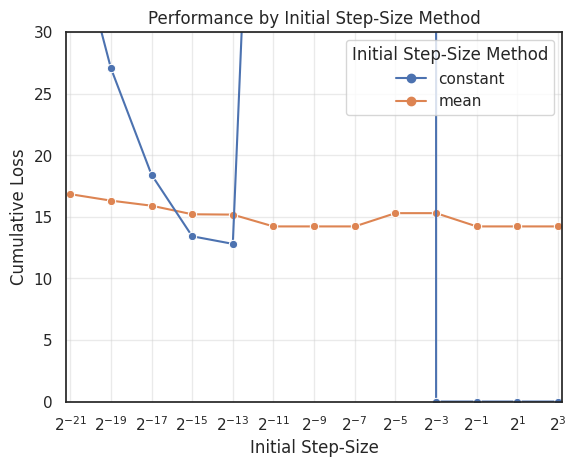

In [14]:
# plot_run_df = pd.concat([cbp_utility_run_df, signed_utility_run_df])
# plot_config_df = pd.concat([cbp_utility_config_df, signed_utility_config_df])

plot_param_sensitivity(
    run_df = run_dfs['mean_initial_step_size'],
    config_df = config_dfs['mean_initial_step_size'],
    x_col = 'optimizer|learning_rate',
    title = 'Performance by Initial Step-Size Method',
    x_label = 'Initial Step-Size',
    y_label = 'Loss',
    hue_col = 'feature_recycling|initial_step_size_method',
    metric_type = 'final_avg',
    legend_title = 'Initial Step-Size Method',
    pow_2_x_axis = True,
)
plt.axhline(ideal_loss, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
plt.ylim(0.0, 0.05)
plt.show()

plot_param_sensitivity(
    run_df = run_dfs['mean_initial_step_size'],
    config_df = config_dfs['mean_initial_step_size'],
    x_col = 'optimizer|learning_rate',
    title = 'Performance by Initial Step-Size Method',
    x_label = 'Initial Step-Size',
    y_label = 'Loss',
    hue_col = 'feature_recycling|initial_step_size_method',
    metric_type = 'cumulative',
    legend_title = 'Initial Step-Size Method',
    pow_2_x_axis = True,
)
plt.ylim(0.0, 30)
plt.show()
    